In [1]:
import pandas as pd 
clip_meta_df = pd.read_csv("../recordings_log.csv")
clip_meta_df.head()
clip_meta_df.columns = clip_meta_df.columns.str.strip().str.replace(" ", "_")
clip_meta_df = clip_meta_df.dropna(subset=["Outcome"])

In [2]:
import pandas as pd

# 📂 Load metadata
clip_meta_df = pd.read_csv("../recordings_log.csv")
clip_meta_df.tail()

# 🧹 Clean column names
clip_meta_df.columns = clip_meta_df.columns.str.strip().str.replace(" ", "_")

# 🧼 Drop rows missing 'Outcome'
clip_meta_df = clip_meta_df.dropna(subset=["Outcome"])

# 📁 Add file paths
clip_meta_df["Video_Path"] = "../" + clip_meta_df["Video_Filename"].str.strip()
clip_meta_df["Audio_Path"] = "../" + clip_meta_df["Audio_Filename"].str.strip()

# 🔧 Convert Outcome to numeric label
clip_meta_df["label"] = clip_meta_df["Outcome"].astype(int)

# 🧪 DEBUG BLOCK — inspect results
print("========== METADATA DEBUG ==========")
print("✅ DataFrame shape:", clip_meta_df.shape)
print("✅ Columns:", clip_meta_df.columns.tolist())
print("✅ Sample rows:")
print(clip_meta_df[["Video_Filename", "Audio_Filename", "label"]].head())
print("✅ Label value counts:")
print(clip_meta_df["label"].value_counts(dropna=False))
print("✅ Unique labels:", clip_meta_df["label"].unique())
print("✅ Sample Video_Filenames:", clip_meta_df["Video_Filename"].head().tolist())
print("✅ Sample Audio_Filenames:", clip_meta_df["Audio_Filename"].head().tolist())
print("====================================")


========== METADATA DEBUG ==========
✅ DataFrame shape: (256, 7)
✅ Columns: ['Timestamp', 'Audio_Filename', 'Video_Filename', 'Outcome', 'Video_Path', 'Audio_Path', 'label']
✅ Sample rows:
                          Video_Filename  \
0  CroppedClips\clip_20250722_124710.avi   
1  CroppedClips\clip_20250722_124740.avi   
2  CroppedClips\clip_20250722_124811.avi   
3  CroppedClips\clip_20250722_124825.avi   
4  CroppedClips\clip_20250722_124846.avi   

                           Audio_Filename  label  
0  CroppedAudio\audio_20250722_124710.wav      0  
1  CroppedAudio\audio_20250722_124740.wav      0  
2  CroppedAudio\audio_20250722_124811.wav      0  
3  CroppedAudio\audio_20250722_124825.wav      0  
4  CroppedAudio\audio_20250722_124846.wav      0  
✅ Label value counts:
label
1    141
0    115
Name: count, dtype: int64
✅ Unique labels: [0 1]
✅ Sample Video_Filenames: ['CroppedClips\\clip_20250722_124710.avi', 'CroppedClips\\clip_20250722_124740.avi', 'CroppedClips\\clip_20250722_12481

In [3]:
import librosa
import numpy as np
import pandas as pd

def extract_mfcc(audio_path):
    y, sr = librosa.load(audio_path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    return np.mean(mfcc, axis=1)  # Clip-level summary

audio_features = []

for idx, row in clip_meta_df.iterrows():
    audio_path = row["Audio_Path"]
    video_name = row["Video_Filename"]
    label = row.get("label", None)

    try:
        mfcc_vec = extract_mfcc(audio_path)
        audio_features.append({
            "Video_Filename": video_name,
            "label": label,
            **{f"mfcc_{i}": mfcc_vec[i] for i in range(len(mfcc_vec))}
        })
    except Exception as e:
        print(f"⚠️ MFCC extraction failed on {audio_path}: {e}")

audio_df = pd.DataFrame(audio_features)



In [3]:
from xgboost import XGBClassifier
import pandas as pd

# 🚀 Load model
face_model = XGBClassifier()
face_model.load_model("xgb_face_model.json")

# 📂 Load landmark features
landmark_df = pd.read_csv("normalized_landmark_data.csv")

# 🧠 Extract features and predict
X_face = landmark_df.drop(columns=["Video_Filename", "frame", "label"])
landmark_df["face_score"] = face_model.predict_proba(X_face)[:, 1]

# 🔄 Average predictions per video
face_preds = landmark_df.groupby("Video_Filename")["face_score"].mean().reset_index()

face_score_list = landmark_df["face_score"].to_list()


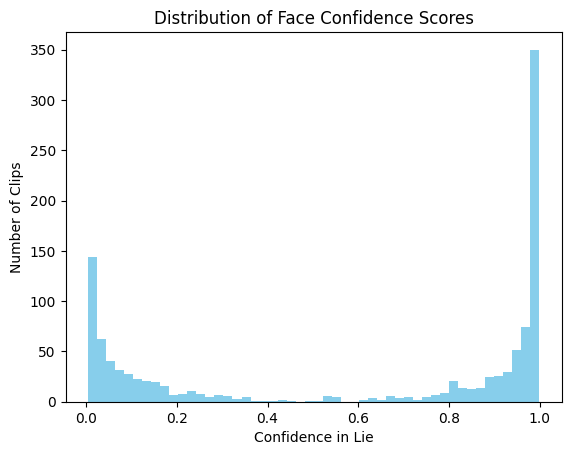

In [5]:
import matplotlib.pyplot as plt
plt.hist(face_score_list, bins=50, color='skyblue')
plt.title("Distribution of Face Confidence Scores")
plt.xlabel("Confidence in Lie")
plt.ylabel("Number of Clips")
plt.show()

In [6]:
# Standardize video keys
clip_meta_df["Video_Filename"] = clip_meta_df["Video_Filename"].str.replace("CroppedClips\\", "", regex=False)
audio_df["Video_Filename"] = audio_df["Video_Filename"].str.replace("CroppedClips\\", "", regex=False).str.strip()
face_preds["Video_Filename"] = face_preds["Video_Filename"].str.strip()
audio_df["Video_Filename"] = audio_df["Video_Filename"].str.strip()

print("Metadata size:", clip_meta_df.shape[0])
print("Face preds size:", face_preds.shape[0])
print("Audio preds size:", audio_df.shape[0])

# Check matching keys
print("Videos in metadata:", set(clip_meta_df["Video_Filename"][:5]))
print("Videos in face_preds:", set(face_preds["Video_Filename"][:5]))

print("\n✅ Sample keys from each source:")
print("Metadata keys:", set(clip_meta_df["Video_Filename"][:10]))
print("Face preds keys:", set(face_preds["Video_Filename"][:10]))
print("Audio preds keys:", set(audio_df["Video_Filename"][:10]))

# Optional: intersection size
print("🔗 Face ∩ Metadata:", len(set(face_preds["Video_Filename"]) & set(clip_meta_df["Video_Filename"])))
print("🔗 Audio ∩ Metadata:", len(set(audio_df["Video_Filename"]) & set(clip_meta_df["Video_Filename"])))



Metadata size: 256
Face preds size: 225
Audio preds size: 256
Videos in metadata: {'clip_20250722_124740.avi', 'clip_20250722_124811.avi', 'clip_20250722_124825.avi', 'clip_20250722_124710.avi', 'clip_20250722_124846.avi'}
Videos in face_preds: {'clip_20250722_124740.avi', 'clip_20250722_124811.avi', 'clip_20250722_124825.avi', 'clip_20250722_124710.avi', 'clip_20250722_124846.avi'}

✅ Sample keys from each source:
Metadata keys: {'clip_20250722_124740.avi', 'clip_20250722_124811.avi', 'clip_20250722_125014.avi', 'clip_20250722_124908.avi', 'clip_20250722_124825.avi', 'clip_20250722_125124.avi', 'clip_20250722_125035.avi', 'clip_20250722_124710.avi', 'clip_20250722_124927.avi', 'clip_20250722_124846.avi'}
Face preds keys: {'clip_20250722_124740.avi', 'clip_20250722_124811.avi', 'clip_20250722_125014.avi', 'clip_20250722_124908.avi', 'clip_20250722_124825.avi', 'clip_20250722_125124.avi', 'clip_20250722_125035.avi', 'clip_20250722_124710.avi', 'clip_20250722_124927.avi', 'clip_20250722_

In [7]:
# 📦 Start with metadata + labels
ensemble_df = clip_meta_df[["Video_Filename", "label"]].copy()

# 🧠 Merge facial predictions
ensemble_df = ensemble_df.merge(
    face_preds[["Video_Filename", "face_score"]],
    on="Video_Filename",
    how="inner"
)

# 🔊 Merge audio features
ensemble_df = ensemble_df.merge(
    audio_df[["Video_Filename"] + [f"mfcc_{i}" for i in range(13)]],
    on="Video_Filename",
    how="inner"
)

# 🎯 Final stacked inputs and target
X_stack = ensemble_df[["face_score"] + [f"mfcc_{i}" for i in range(13)]]
y_stack = ensemble_df["label"]

# ✅ Sanity check
print("✅ Final ensemble shape:", ensemble_df.shape)
print("✅ Label distribution:\n", y_stack.value_counts(dropna=False))
print("✅ Sample stacked features:\n", X_stack.head())


✅ Final ensemble shape: (303, 16)
✅ Label distribution:
 label
1    192
0    111
Name: count, dtype: int64
✅ Sample stacked features:
    face_score      mfcc_0     mfcc_1     mfcc_2     mfcc_3     mfcc_4  \
0    0.092273 -443.265900  56.664082 -17.217901  13.718971  -6.519683   
1    0.011475 -684.949036  53.253754  -2.427891  -1.850195   3.063167   
2    0.006264 -579.864868  71.057129  -5.618330  -5.488316  -6.368209   
3    0.070553 -568.717102  46.314335  -1.432767   2.496445  -7.141501   
4    0.010818 -503.738922  61.163746  -3.829136  12.440789 -16.666857   

      mfcc_5     mfcc_6     mfcc_7     mfcc_8     mfcc_9    mfcc_10   mfcc_11  \
0  -3.886679 -10.582273 -29.840578 -12.004639   0.837918 -10.145561 -7.091199   
1  -0.970450 -15.641531 -10.608442  -4.013901  -5.318762  -5.764741 -3.139401   
2  -7.878674 -25.342104 -11.862755  -6.414837  -2.586096 -17.548067 -9.078303   
3  -0.892620 -13.783896 -13.445086  -3.848600  -4.180815 -12.204113 -5.216664   
4 -10.564239 -20.3244

In [8]:
print("Final columns:", ensemble_df.columns)
print("Label counts:", y_stack.value_counts())


Final columns: Index(['Video_Filename', 'label', 'face_score', 'mfcc_0', 'mfcc_1', 'mfcc_2',
       'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9',
       'mfcc_10', 'mfcc_11', 'mfcc_12'],
      dtype='object')
Label counts: label
1    192
0    111
Name: count, dtype: int64


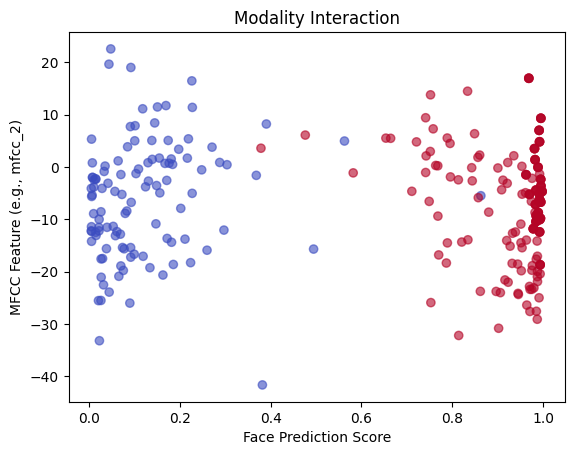

In [9]:
import matplotlib.pyplot as plt

plt.scatter(ensemble_df["face_score"], ensemble_df["mfcc_2"], c=ensemble_df["label"], cmap="coolwarm", alpha=0.6)
plt.xlabel("Face Prediction Score")
plt.ylabel("MFCC Feature (e.g., mfcc_2)")
plt.title("Modality Interaction")
plt.show()





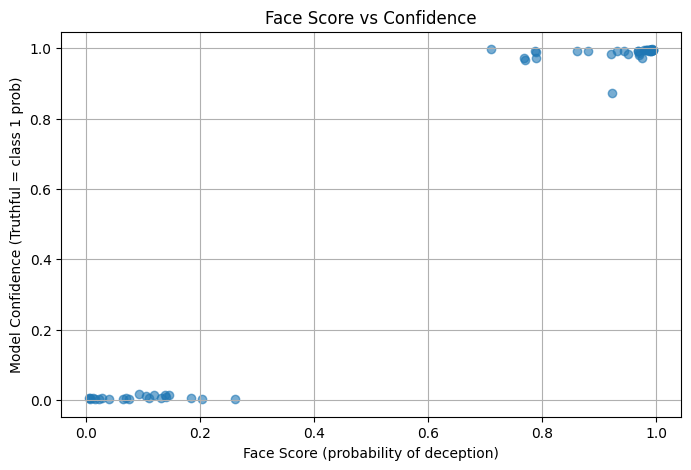

In [15]:
# Plot face_score vs confidence
# After getting predictions:
y_proba = stacked_model.predict_proba(X_test)

# Extract class 1 confidence scores (TRUTHFUL)
conf_scores = y_proba[:, 1]

# Add to a new DataFrame for analysis
eval_df = X_test.copy()
eval_df["label"] = y_test
eval_df["conf_score"] = conf_scores


plt.figure(figsize=(8,5))
plt.scatter(eval_df["face_score"], eval_df["conf_score"], alpha=0.6)
plt.title("Face Score vs Confidence")
plt.xlabel("Face Score (probability of deception)")
plt.ylabel("Model Confidence (Truthful = class 1 prob)")
plt.grid(True)
plt.show()

In [16]:
y_proba = stacked_model.predict_proba(X_test)
eval_df = X_test.copy()
eval_df["label"] = y_test
eval_df["conf_score"] = y_proba[:, 1]  # class 1 = predicted TRUTHFUL
eval_df["face_score"] = X_test["face_score"]

# Now check correlation
print("🔁 Correlation between face_score and confidence:")
print(eval_df[["face_score", "conf_score"]].corr())


🔁 Correlation between face_score and confidence:
            face_score  conf_score
face_score    1.000000    0.983704
conf_score    0.983704    1.000000



✅ Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00        39

    accuracy                           1.00        61
   macro avg       1.00      1.00      1.00        61
weighted avg       1.00      1.00      1.00        61

✅ Confusion Matrix:
[[22  0]
 [ 0 39]]


C:\Users\connellj2\OneDrive - Wentworth Institute of Technology\Documents\DecepTech\decep_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:59:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<Figure size 1000x600 with 0 Axes>

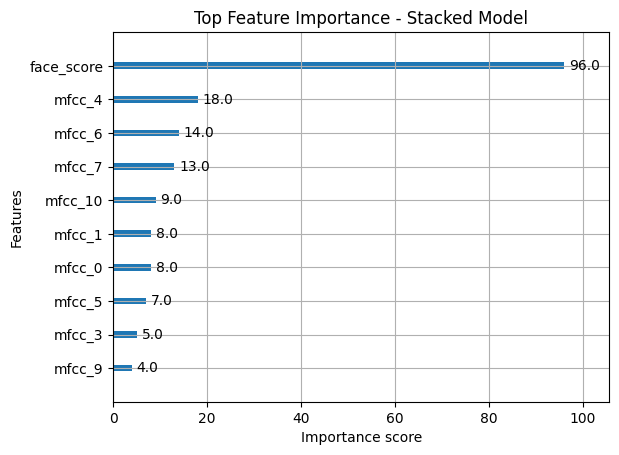

In [10]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 🔄 Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_stack, y_stack, test_size=0.2, stratify=y_stack, random_state=42
)

# ⚙️ Initialize and train XGBoost
stacked_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # handling class imbalance
    use_label_encoder=False,
    eval_metric="logloss"
)

stacked_model.fit(X_train, y_train)

# 🧪 Evaluate performance
y_pred = stacked_model.predict(X_test)

print("\n✅ Classification Report:")
print(classification_report(y_test, y_pred))

print("✅ Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 📊 Feature Importance
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(10, 6))
plot_importance(stacked_model, max_num_features=10)
plt.title("Top Feature Importance - Stacked Model")
plt.show()


In [44]:
import joblib

joblib.dump(stacked_model, "stacked_model.pkl")

['stacked_model.pkl']